In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 3.1
# To read csv
df = pd.read_csv("/content/drive/MyDrive/Coursework/Coursework.csv")

**1. Data Exploration and Understanding:**


*Dataset Overview*

In [ ]:
# 1. Load the dataset and display the first 10 rows
df.head(10)

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298
5,Netherlands,7.319,1.901,1.462,0.706,0.725,0.247,0.372,1.906
6,Norway,7.302,1.952,1.517,0.704,0.835,0.224,0.484,1.586
7,Luxembourg,7.122,2.141,1.355,0.708,0.801,0.146,0.432,1.540
8,Switzerland,7.060,1.970,1.425,0.747,0.759,0.173,0.498,1.488
9,Australia,7.057,1.854,1.461,0.692,0.756,0.225,0.323,1.745


In [ ]:
# 2. Identify the number of rows and columns in the dataset.

print("No. of (Rows, Columns): ", df.shape)

No. of (Rows, Columns):  (143, 9)


In [ ]:
# 3. List all the columns and their data types.
df.dtypes

,0
Country name,object
score,float64
Log GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64
Dystopia + residual,float64


In [ ]:
# 1. Calculate the mean, median, and standard deviation for the Score column.

df["score"].agg(['mean', 'median', 'std'])

,score
mean,5.527580
median,5.785000
std,1.170717


In [ ]:
# 2. Identify the country with the highest and lowest happiness scores.

happiest = df.loc[df['score'].idxmax()]
saddest = df.loc[df['score'].idxmin()]

print(f"\nHappiest Country is {happiest['Country name']} with ({happiest['score']})")
print(f"Least Happy Country is {saddest['Country name']} with ({saddest['score']})")



Happiest Country is Finland with (7.741)
Least Happy Country is Afghanistan with (1.721)


*Missing Values*

In [ ]:
# Check if there are any missing values in the dataset. If so, display the total count for each column.

# Count missing values
missing = df.isnull().sum()

# Labelling the columns
missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})


print(missing_df)



                         Column  Missing Values
0                  Country name               0
1                         score               0
2            Log GDP per capita               3
3                Social support               3
4       Healthy life expectancy               3
5  Freedom to make life choices               3
6                    Generosity               3
7     Perceptions of corruption               3
8           Dystopia + residual               3


Filtering and Sorting

In [ ]:
# 1. Filter the dataset to show only the countries with a Score greater than 7.5.
high_score_df = df[df['score'] > 7.5].copy()

high_score_df


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050


In [ ]:
top_gdp_high_score = high_score_df.sort_values(by='Log GDP per capita', ascending=False).head(10)

print("\nCountries with Score > 7.5 sorted by GDP:")
display(top_gdp_high_score[['Country name', 'score', 'Log GDP per capita']])


Countries with Score > 7.5 sorted by GDP:


,Country name,score,Log GDP per capita
1,Denmark,7.583,1.908
2,Iceland,7.525,1.881
0,Finland,7.741,1.844


*Adding New Columns*

In [ ]:
def categorize_happiness(score):
    if score < 4:
        return 'Low'
    elif 4 <= score <= 6:
        return 'Medium'
    else:
        return 'High'

df['Happiness_Category'] = df['score'].apply(categorize_happiness)

print("\nCategory Counts:")
print(df['Happiness_Category'].value_counts())


Category Counts:
Happiness_Category
Medium    70
High      56
Low       17
Name: count, dtype: int64


*Data VIsualizations:*

/tmp/ipython-input-892054485.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='score', y='Country name', palette='viridis')


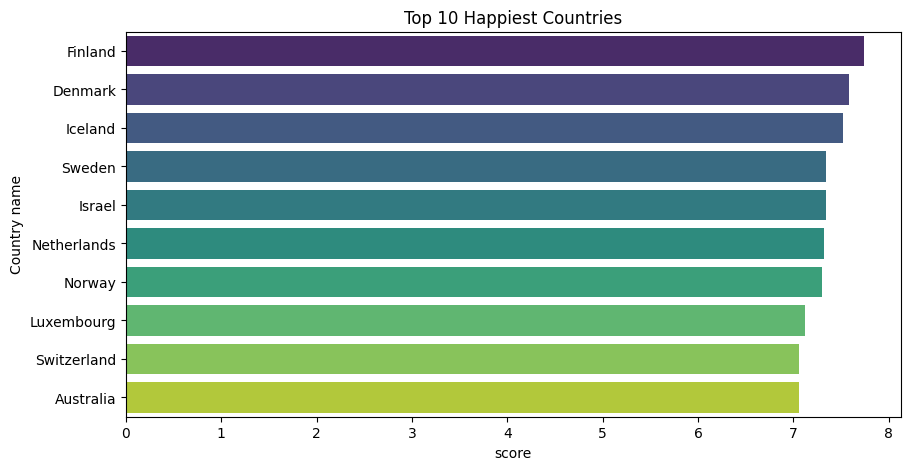

In [ ]:
# Bar Plot: Plot the top 10 happiest countries by Score using a bar chart.

top10 = df.nlargest(10, 'score')
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='score', y='Country name', palette='viridis')
plt.title('Top 10 Happiest Countries')
plt.show()


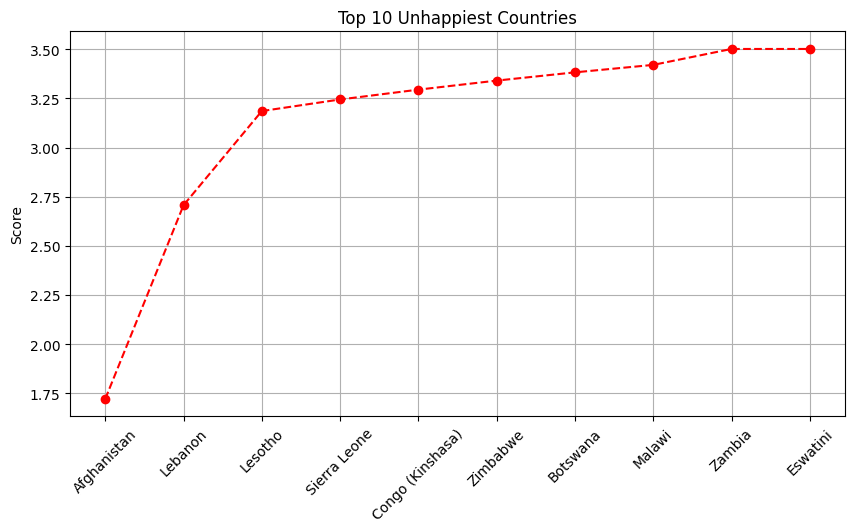

In [ ]:
#  Top 10 Unhappiest
bottom10 = df.nsmallest(10, 'score')
plt.figure(figsize=(10, 5))
plt.plot(bottom10['Country name'], bottom10['score'], marker='o', color='red', linestyle='--')
plt.title('Top 10 Unhappiest Countries')
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.grid(True)
plt.show()

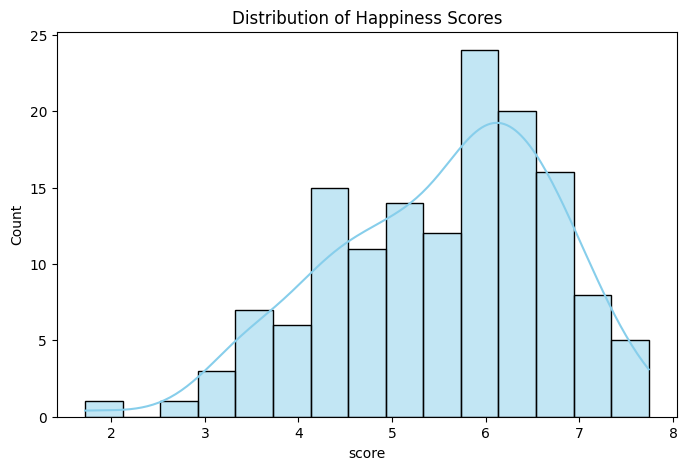

In [ ]:
# 3. Histogram of Score
plt.figure(figsize=(8, 5))
sns.histplot(df['score'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Happiness Scores')
plt.xlabel('score')
plt.show()

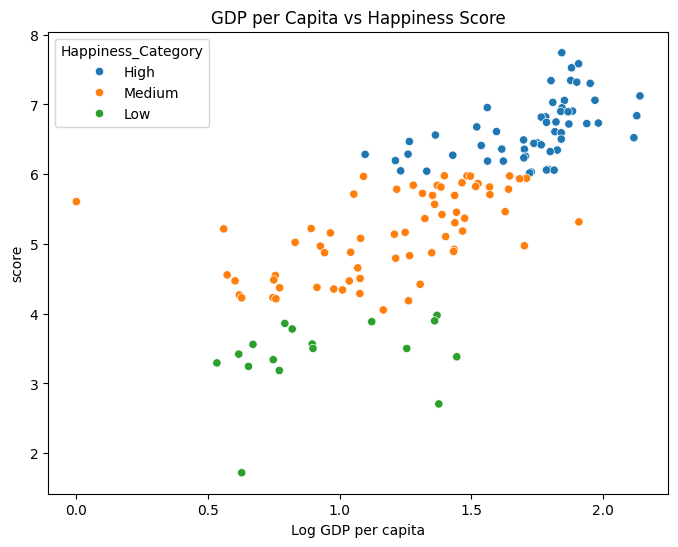

In [ ]:
# 4. Scatter Plot (GDP vs Score)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Log GDP per capita', y='score', hue='Happiness_Category')
plt.title('GDP per Capita vs Happiness Score')
plt.show()

**Problem - 2 - Some Advance Data Exploration Task:**

*Task - 1 - Setup Task - Preparing the South-Asia Dataset:*

In [ ]:
sa_countries_list = ["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

# Define the countries in South Asia

# Filtering
sa_df = df[df['Country name'].isin(sa_countries_list)].copy()

print("South Asian Countries found in dataset:")
print(sa_df['Country name'].unique())

sa_df.to_csv('South_Asia_Dataset.csv', index=False)


South Asian Countries found in dataset:
['Nepal' 'Pakistan' 'India' 'Sri Lanka' 'Bangladesh' 'Afghanistan']


*Task 2: Composite Score Ranking*

In [ ]:
sa_df['Composite Score'] = (
    0.40 * sa_df['Log GDP per capita'] + 0.30 * sa_df['Social support']
    +  0.30 * sa_df['Healthy life expectancy']
)

sa_ranked = sa_df.sort_values(by='Composite Score', ascending=False)


/tmp/ipython-input-932580643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sa_ranked.head(5), x='Composite Score', y='Country name', palette='magma')


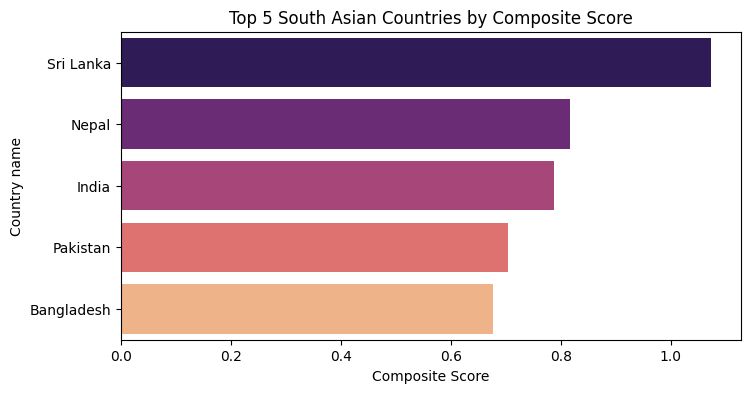

In [ ]:
# Visualize Top 5
plt.figure(figsize=(8, 4))
sns.barplot(data=sa_ranked.head(5), x='Composite Score', y='Country name', palette='magma')
plt.title('Top 5 South Asian Countries by Composite Score')
plt.show()


Comparison of Rankings:
    Country name  score  Composite Score
127    Sri Lanka  3.898           1.0739
92         Nepal  5.158           0.8159
125        India  4.054           0.7874
107     Pakistan  4.657           0.7039
128   Bangladesh  3.886           0.6774
142  Afghanistan  1.721           0.3238


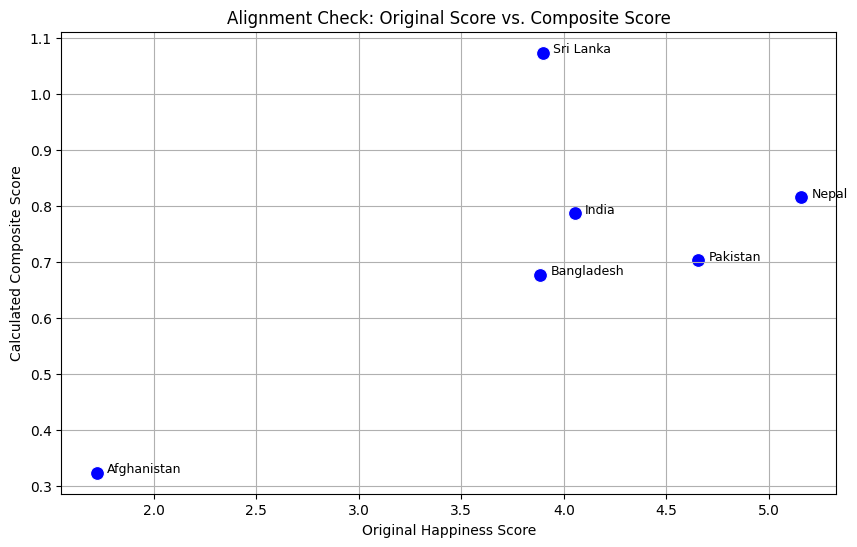

In [ ]:
# Original Rank vs Composite Rank
print("\nComparison of Rankings:")
print(sa_ranked[['Country name', 'score', 'Composite Score']])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sa_df, x='score', y='Composite Score', s=100, color='blue')

# Add labels for countries
for i in range(sa_df.shape[0]):
    plt.text(
        sa_df.iloc[i]['score'] + 0.05,
        sa_df.iloc[i]['Composite Score'],
        sa_df.iloc[i]['Country name'],
        fontsize=9
    )

plt.title('Alignment Check: Original Score vs. Composite Score')
plt.xlabel('Original Happiness Score')
plt.ylabel('Calculated Composite Score')
plt.grid(True)
plt.show()